In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

base_dir = "C:/Users/ismas/Documents/X2Learn/Personalization-Enablers-Training-Tools"

## Raw data

In [46]:
# Data
data_dir = base_dir + "/datasets/XRoom/"
participant_example = os.listdir(data_dir)[0]
shimmer_files = [f for f in os.listdir(data_dir + participant_example) if "shimmer" in f.lower()]
data_example = shimmer_files[2]

print(participant_example + "/" + data_example)
data = pd.read_csv(data_dir + participant_example + "/" + data_example)
data.head()

Participants_12_FS/data_collection_638684943237742917_SHIMMER_.csv


,timestamp,int_timestamp,accel_x,accel_y,accel_z,gsr,ppg,hr
0,638684943111512078,1.732894e+12,-4.293478,8.445652,3.086957,888.636812,1252.747253,-1
1,638684943112511921,1.732894e+12,-3.978261,8.152174,2.673913,889.689907,1288.644689,-1
2,638684943113553806,1.732894e+12,-4.413043,7.967391,2.586957,890.393358,1566.300366,-1
3,638684943114540380,1.732894e+12,-4.228261,7.967391,2.913043,891.450623,1344.322344,-1
4,638684943115543565,1.732894e+12,-3.826087,8.489130,3.152174,892.156863,1280.586081,-1


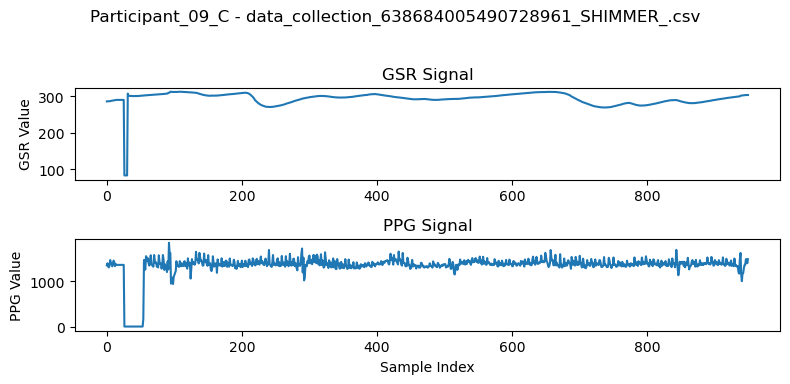

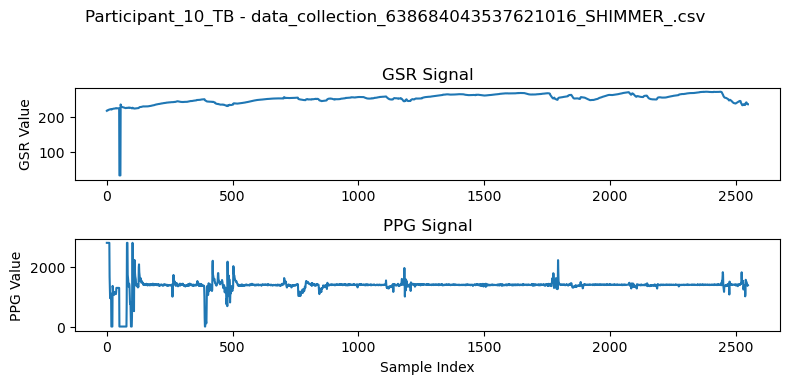

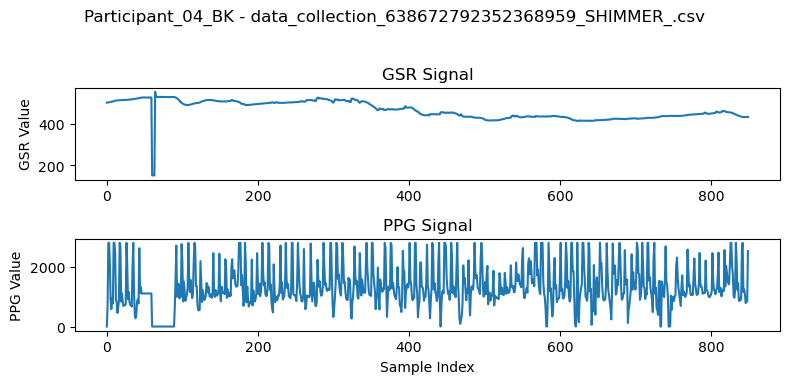

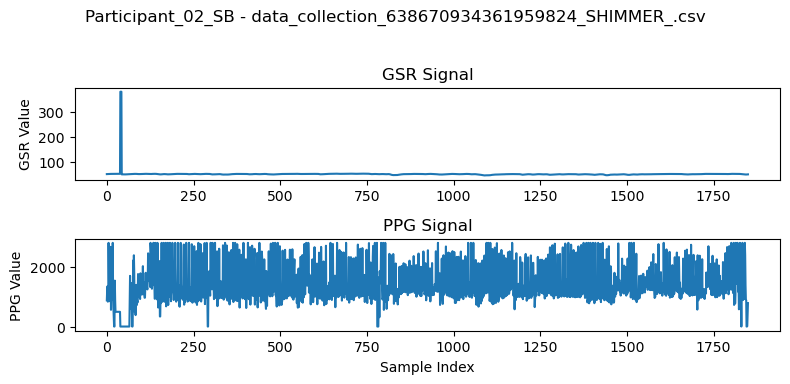

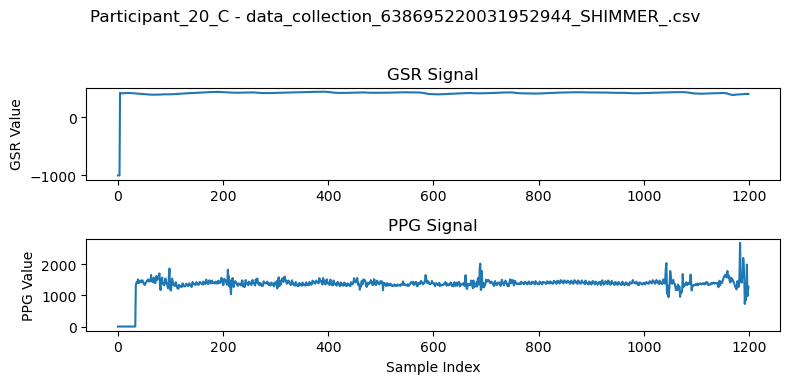

In [3]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_raw_data_samples(data_dir, num_samples_to_return, visualize=False):
    """
    Retrieves and optionally visualizes random raw GSR and PPG data samples from XRoom dataset,
    returning a list of dictionaries containing the relevant data as a NumPy array.
    Randomly selects a participant and then a non-empty SHIMMER_ CSV file for each sample.

    Args:
        data_dir (str): The path to the directory containing participant data.
        num_samples_to_return (int): The number of random samples to retrieve/visualize.
        visualize (bool, optional): If True, plots the GSR and PPG signals for each sample.
                                     Defaults to False.

    Returns:
        list: A list of dictionaries, where each dictionary contains:
              - 'data' (numpy.ndarray): A 2D NumPy array with 'timestamp', 'gsr', and 'ppg' data.
                                        If a signal is missing, its column will be filled with NaNs.
              - 'filename' (str): The name of the CSV file the data was loaded from.
    """

    # Get a list of all participant directories
    all_participants = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and d.startswith('Participant_')]

    results = []

    if not all_participants:
        print("No participant directories found in the specified data directory.")
        return results

    # Loop until we have the desired number of samples or exhaust possibilities
    attempts = 0
    max_attempts = num_samples_to_return * 5 # Prevent infinite loops if data is sparse
    while len(results) < num_samples_to_return and attempts < max_attempts:
        attempts += 1
        
        # Randomly select a participant for this sample
        participant = random.choice(all_participants)
        participant_path = os.path.join(data_dir, participant)

        # Get all CSV files ending with _SHIMMER_.csv for the current participant
        shimmer_files = [f for f in os.listdir(participant_path) if f.endswith('_SHIMMER_.csv')]

        if not shimmer_files:
            continue # Try another participant if this one has no SHIMMER files

        # Randomly select one non-empty CSV file from this participant
        random.shuffle(shimmer_files) # Shuffle to pick randomly
        selected_file_path = None
        selected_file_name = None
        for filename in shimmer_files:
            file_path = os.path.join(participant_path, filename)
            try:
                temp_data = pd.read_csv(file_path)
                if not temp_data.empty:
                    selected_file_path = file_path
                    selected_file_name = filename
                    break
            except pd.errors.EmptyDataError:
                # print(f"File {filename} for {participant} is empty or malformed. Trying another.") # Can be noisy
                continue

        if selected_file_path is None:
            continue # Try another participant if no valid file was found for this one

        data_df = pd.read_csv(selected_file_path)

        if visualize:
            fig, axes = plt.subplots(2, 1, figsize=(8, 4))
            fig.suptitle(f'{participant} - {selected_file_name}', fontsize=12)

            if 'gsr' in data_df.columns:
                axes[0].plot(data_df['gsr'])
                axes[0].set_title('GSR Signal')
                axes[0].set_ylabel('GSR Value')
            else:
                axes[0].set_title('GSR Signal (Not Available)')
                axes[0].axis('off') # Hide axes if data not present

            if 'ppg' in data_df.columns:
                axes[1].plot(data_df['ppg'])
                axes[1].set_title('PPG Signal')
                axes[1].set_xlabel('Sample Index')
                axes[1].set_ylabel('PPG Value')
            else:
                axes[1].set_title('PPG Signal (Not Available)')
                axes[1].axis('off') # Hide axes if data not present

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show()

        # Prepare the NumPy array for return
        timestamp_data = data_df['timestamp'].values
        gsr_data = data_df['gsr'].values if 'gsr' in data_df.columns else np.full(len(data_df), np.nan)
        ppg_data = data_df['ppg'].values if 'ppg' in data_df.columns else np.full(len(data_df), np.nan)

        results.append({
            'timestamp': timestamp_data,
            'gsr': gsr_data,
            'ppg': ppg_data,
            'filename': selected_file_name
        })
    
    if len(results) < num_samples_to_return:
        print(f"Warning: Could only retrieve {len(results)} samples out of {num_samples_to_return} requested.")

    return results

raw_data_samples = get_raw_data_samples(data_dir, num_samples_to_return=5, visualize=True)

In [4]:
# Calculate sample_rate from samples

raw_data_samples = get_raw_data_samples(data_dir, num_samples_to_return=100, visualize=False)
all_sample_rates = []
for i, sample in enumerate(raw_data_samples):
    time_data = sample["timestamp"]
    sample_rate = time_data.shape[0] / ((time_data[-1] - time_data[0]) / 1e7)
    all_sample_rates.append(sample_rate)
    print(i, sample_rate)

print("Min sample rate:", min(all_sample_rates))
print("Max sample rate:", max(all_sample_rates))
print("Mean sample rate:", np.mean(all_sample_rates))
print("Median sample rate:", np.median(all_sample_rates))

0 9.139793900089707
1 9.190274560749076
2 8.392344065662943
3 8.894357863511148
4 8.168300491038472
5 9.124647791332649
6 7.604580487687631
7 7.573974514547604
8 9.166019822618972
9 7.899979553023448
10 9.166943407139229
11 9.176482424278241
12 9.187910849492768
13 9.11344472958416
14 9.000421176058998
15 6.145799536604803
16 8.931971793188051
17 9.109350429023754
18 7.876107852403917
19 9.356971961109913
20 9.29734489283484
21 8.894357863511148
22 9.344228715933388
23 9.152189219372532
24 9.132158001632837
25 9.072940963018088
26 9.15842252098593
27 9.17893602340736
28 6.662987561516958
29 9.325186898756778
30 9.110827456527149
31 9.207859167303072
32 0.7232117444773606
33 8.392344065662943
34 7.841796826587051
35 8.96262953416786
36 9.11344472958416
37 7.409674483903908
38 7.899979553023448
39 9.163782855313707
40 9.174000306448306
41 7.883732914423302
42 6.145799536604803
43 8.894357863511148
44 9.166019822618972
45 7.604580487687631
46 9.14618800210953
47 5.923713432707675
48 9.038

In [5]:
import datetime
print((time_data[-1] - time_data[0]), (time_data[-1] - time_data[0]) /1e7)
datetime.datetime(1, 1, 1) + datetime.timedelta(microseconds=(time_data[-1] - time_data[0]).astype(float) // 10)

1526070482 152.6070482


datetime.datetime(1, 1, 1, 0, 2, 32, 607048)

## Preprocessed data

In [6]:
# After preprocessing
ssl_dir =  base_dir + "/outputs/XRoom/shimmer/standardize/"
ssl_example = os.listdir(ssl_dir)[0]

processed_data = np.load(ssl_dir + ssl_example)
processed_data.shape

(100, 1)

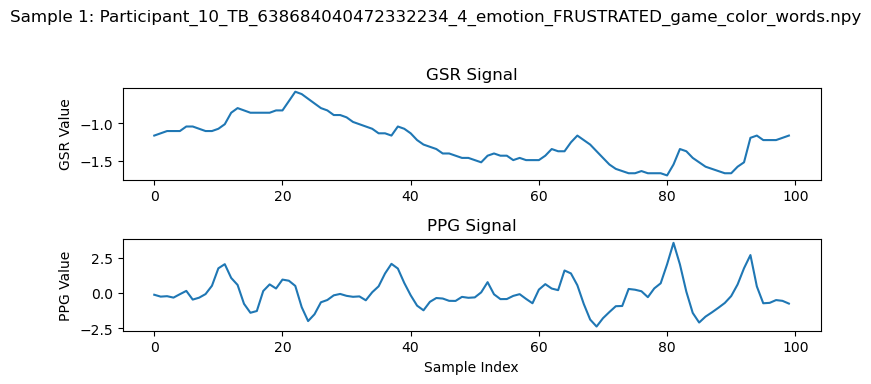

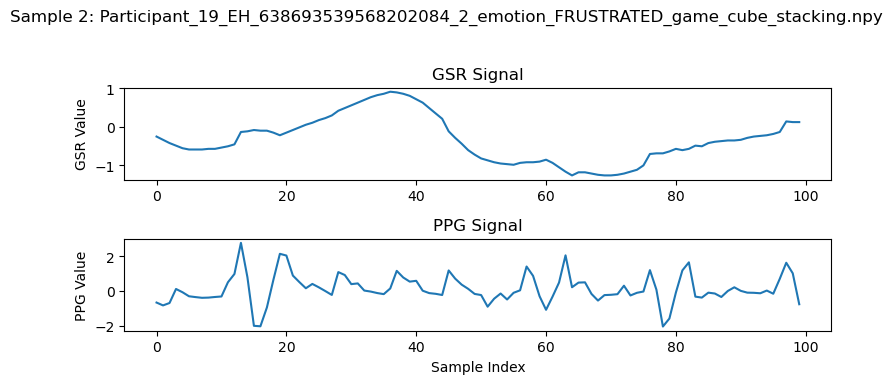

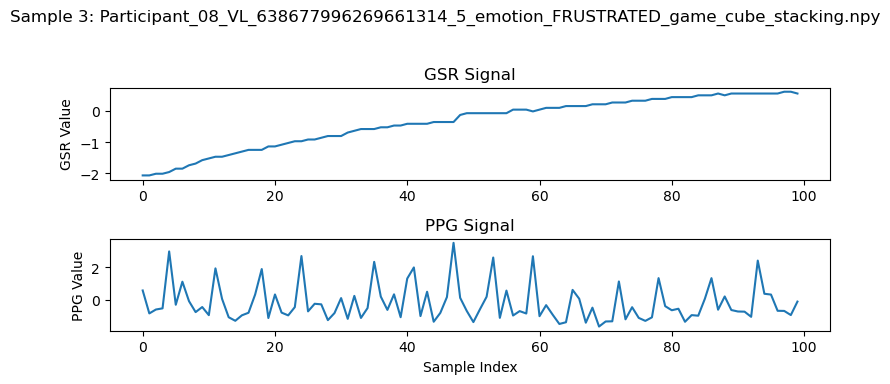

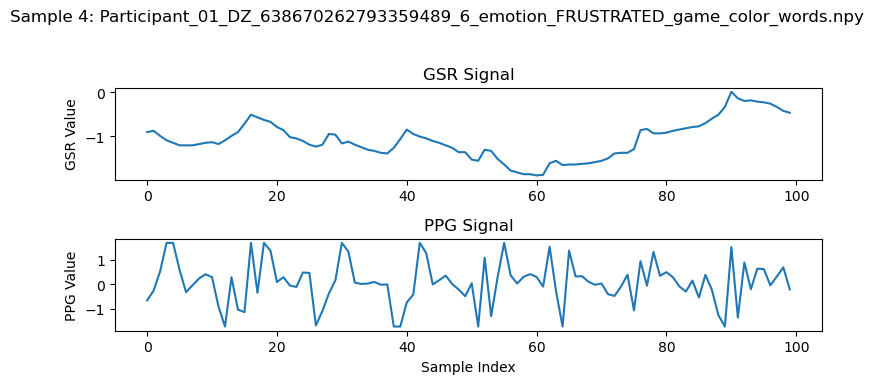

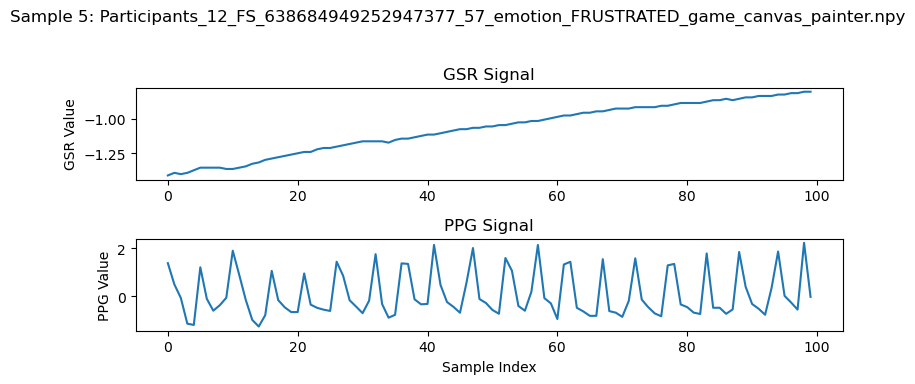

In [49]:
# Visualize random processed samples

def get_processed_samples(data_dir, num_samples_to_process, visualize=False):
    """
    Loads and optionally visualizes processed signal samples from .npy files.

    Args:
        data_dir (str): The directory containing the .npy files.
        num_samples_to_process (int): The number of random samples to load/process.
        visualize (bool, optional): If True, plots the GSR and PPG signals for each sample.
                                     Defaults to False.

    Returns:
        list: A list of dictionaries, where each dictionary contains 'filename' and 'data'
              (the loaded numpy array) for a successfully processed sample.
              Returns an empty list if no samples could be processed.
    """
    processed_samples = []
    all_npy_files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]

    if not all_npy_files:
        print(f"No .npy files found in {data_dir}.")
        return []

    if len(all_npy_files) < num_samples_to_process:
        print(f"Warning: Not enough .npy files ({len(all_npy_files)}) to select {num_samples_to_process} samples. Processing all available files.")
        selected_files = all_npy_files
    else:
        selected_files = random.sample(all_npy_files, num_samples_to_process)

    for i, filename in enumerate(selected_files):
        file_path = os.path.join(data_dir, filename)
        
        current_sample_data = {'filename': filename, 'data': None}

        try:
            loaded_array = np.load(file_path)
            
            if loaded_array.shape[1] == 2:
                current_sample_data['gsr'] = loaded_array[:, 0]
                current_sample_data['ppg'] = loaded_array[:, 1]
            elif loaded_array.shape[1] == 1:
                current_sample_data['gsr'] = loaded_array[:, 0]
            else:
                print(f"File {filename} has unexpected shape {loaded_array.shape}. Expected (X, 1) or (X, 2). Skipping.")
                continue

        except Exception as e:
            print(f"Error loading or parsing {filename}: {e}. Skipping.")
            continue

        processed_samples.append(current_sample_data)

        if visualize:
            fig, axes = plt.subplots(2, 1, figsize=(8, 4))
            fig.suptitle(f'Sample {i+1}: {os.path.basename(filename)}', fontsize=12)

            gsr_signal = current_sample_data['gsr']
            ppg_signal = current_sample_data['ppg'] if 'ppg' in current_sample_data else None

            gsr_present = gsr_signal is not None and len(gsr_signal) > 0
            ppg_present = ppg_signal is not None and len(ppg_signal) > 0

            if gsr_present:
                axes[0].plot(gsr_signal)
                axes[0].set_title('GSR Signal')
                axes[0].set_ylabel('GSR Value')
            else:
                axes[0].set_title('GSR Signal (Not Available)')
                axes[0].axis('off')

            if ppg_present:
                axes[1].plot(ppg_signal)
                axes[1].set_title('PPG Signal')
                axes[1].set_xlabel('Sample Index')
                axes[1].set_ylabel('PPG Value')
            else:
                axes[1].set_title('PPG Signal (Not Available)')
                axes[1].axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
    
    return processed_samples

processed_samples = get_processed_samples(ssl_dir, 5, visualize=True)

## Neurokit processing

In [50]:
import neurokit2 as nk

### Examples from the library

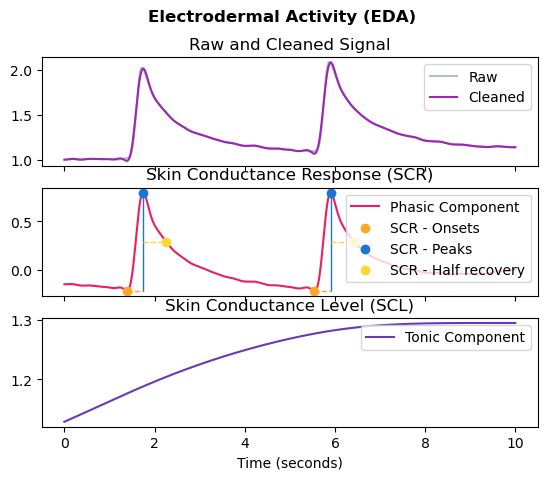

In [9]:
# Generate 10 seconds of EDA signal (recorded at 250 samples / second) with 2 SCR peaks
eda = nk.eda_simulate(duration=10, sampling_rate=250, scr_number=2, drift=0.01)

# Process it
signals, info = nk.eda_process(eda, sampling_rate=250)

# Visualise the processing
nk.eda_plot(signals, info)

In [10]:
# Download the data for event-related analysis
data = nk.data("bio_eventrelated_100hz")

# Process the data for event-related analysis
df, info = nk.bio_process(eda=data["EDA"], sampling_rate=100)

events = nk.events_find(data["Photosensor"], threshold_keep='below',
                         event_conditions=["Negative", "Neutral", "Neutral", "Negative"])

epochs = nk.epochs_create(df, events, sampling_rate=100, epochs_start=-0.1, epochs_end=1.9)

# Analyze
analyze_epochs = nk.eda_analyze(epochs, sampling_rate=100)

analyze_epochs

,Label,Condition,Event_Onset,EDA_Peak_Amplitude,EDA_SCR,SCR_Peak_Amplitude,SCR_Peak_Amplitude_Time,SCR_RiseTime,SCR_RecoveryTime
1,1,Negative,1024,-0.403998,0,NaN,NaN,NaN,NaN
2,2,Neutral,4957,0.409627,0,NaN,NaN,NaN,NaN
3,3,Neutral,9224,0.019098,0,NaN,NaN,NaN,NaN
4,4,Negative,12984,0.045042,0,NaN,NaN,NaN,NaN


In [11]:
data

,ECG,EDA,Photosensor,RSP
0,-0.015869,13.196868,5.0,0.778931
1,-0.011703,13.197173,5.0,0.777588
2,-0.009766,13.197020,5.0,0.777435
3,-0.013321,13.197631,5.0,0.777557
4,-0.009583,13.196715,5.0,0.775299
...,...,...,...,...
14995,-0.007675,14.873656,5.0,1.351868
14996,-0.005203,14.873961,5.0,1.356689
14997,-0.004272,14.874266,5.0,1.361938
14998,-0.000458,14.875335,5.0,1.366821


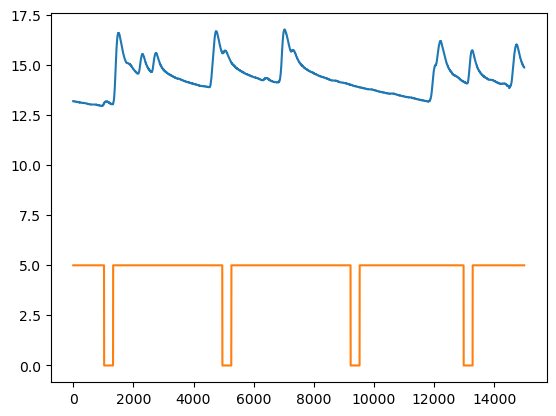

In [12]:
plt.plot(data.index, data['EDA'])
plt.plot(data.index, data['Photosensor'])

In [13]:
epochs["1"].describe()

,EDA_Raw,EDA_Clean,EDA_Tonic,EDA_Phasic,SCR_Onsets,SCR_Peaks,SCR_Height,SCR_Amplitude,SCR_RiseTime,SCR_Recovery,SCR_RecoveryTime,Index
count,200.000000,200.000000,200.000000,200.000000,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.000000
mean,13.146177,13.146137,13.682261,-0.536124,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1113.500000
std,0.032583,0.032552,0.122990,0.128294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.879185
min,13.061522,13.058017,13.481851,-0.806045,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1014.000000
25%,13.123358,13.121035,13.575058,-0.640458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1063.750000
50%,13.151168,13.153620,13.676952,-0.495237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1113.500000
75%,13.172454,13.173773,13.786766,-0.417219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163.250000
max,13.186034,13.186442,13.903433,-0.403998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1213.000000


### Raw data

data_collection_638672797186414901_SHIMMER_.csv


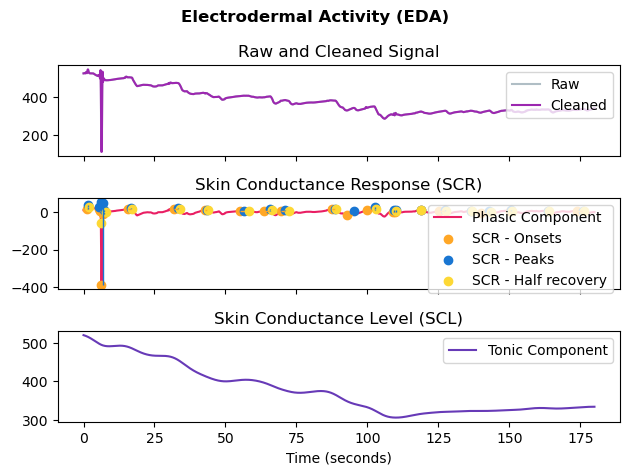

data_collection_638676161683408566_SHIMMER_.csv


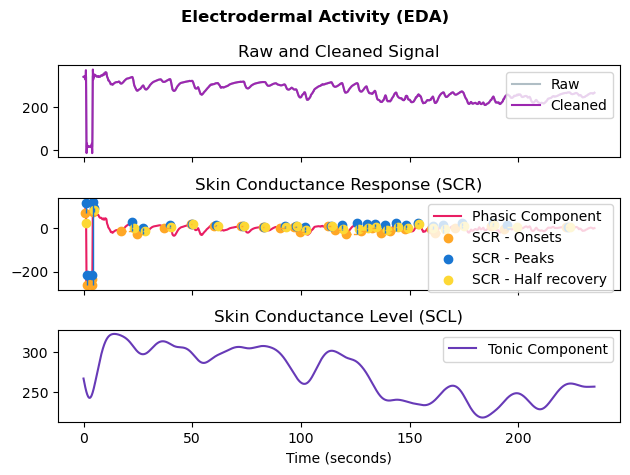

data_collection_638672772241924248_SHIMMER_.csv


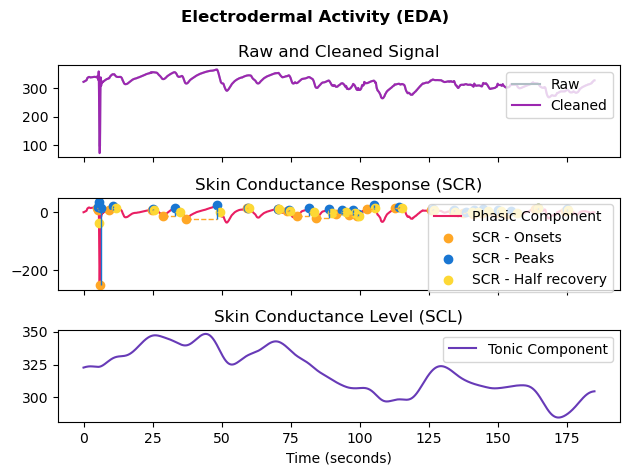

data_collection_638684011430375853_SHIMMER_.csv


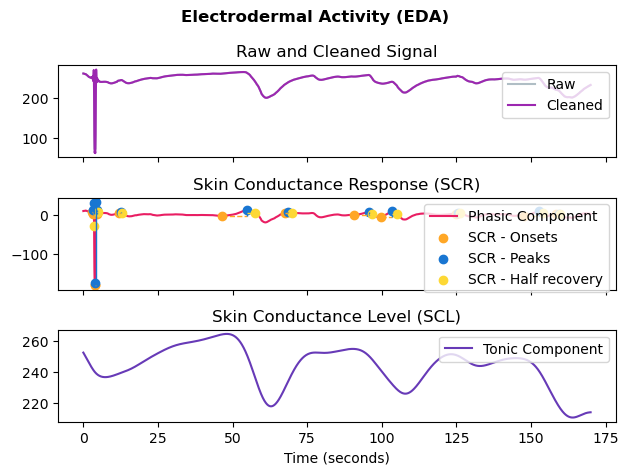

data_collection_638684919935118507_SHIMMER_.csv


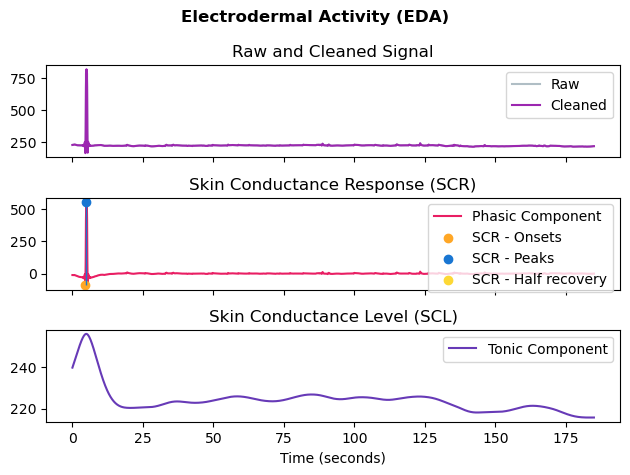

In [ ]:
# Raw data
raw_data_samples = get_raw_data_samples(data_dir, num_samples_to_return=5, visualize=False)

for sample in raw_data_samples:
    print(sample["filename"])

    # EDA / GSR
    eda_signals, eda_info = nk.eda_process(sample["gsr"], sampling_rate=10)

    eda_fig = nk.eda_plot(eda_signals, eda_info)
    plt.tight_layout()
    plt.show()

    # PPG
    # ppg_signals, ppg_info = nk.ppg_process(sample["data"][:,1], sampling_rate=17)

    # ppg_fig = nk.ppg_plot(ppg_signals, ppg_info)
    # plt.tight_layout()
    # plt.show()

In [15]:
eda_info

{'SCR_Onsets': array([46], dtype=int64),
 'SCR_Peaks': array([49], dtype=int64),
 'SCR_Height': array([558.74727719]),
 'SCR_Amplitude': array([650.54225674]),
 'SCR_RiseTime': array([0.3]),
 'SCR_Recovery': array([nan]),
 'SCR_RecoveryTime': array([nan]),
 'sampling_rate': 10}

In [37]:
eda_signals

,EDA_Raw,EDA_Clean,EDA_Tonic,EDA_Phasic,SCR_Onsets,SCR_Peaks,SCR_Height,SCR_Amplitude,SCR_RiseTime,SCR_Recovery,SCR_RecoveryTime
0,-1.014741,-1.014742,-0.972147,-0.036057,0,0,0.000000,0.000000,0.0,0,0.0
1,-1.009108,-1.009200,-0.970069,-0.035368,0,0,0.000000,0.000000,0.0,0,0.0
2,-1.003471,-1.003021,-0.967993,-0.034171,0,1,-0.034171,NaN,NaN,0,0.0
3,-0.997830,-0.998697,-0.965920,-0.034958,0,0,0.000000,0.000000,0.0,0,0.0
4,-0.997830,-0.996800,-0.963851,-0.038303,0,0,0.000000,0.000000,0.0,0,0.0
5,-0.992185,-0.993212,-0.961790,-0.040089,1,0,0.000000,0.000000,0.0,0,0.0
6,-0.986536,-0.985446,-0.959737,-0.037829,0,0,0.000000,0.000000,0.0,0,0.0
7,-0.975227,-0.976298,-0.957696,-0.034321,0,0,0.000000,0.000000,0.0,0,0.0
8,-0.969566,-0.968945,-0.955667,-0.032743,0,1,-0.032743,0.007346,0.3,0,0.0
9,-0.963902,-0.963693,-0.953654,-0.033401,0,0,0.000000,0.000000,0.0,0,0.0


In [17]:
analyze_epochs = nk.eda_analyze(eda_signals, sampling_rate=100)
analyze_epochs

,SCR_Peaks_N,SCR_Peaks_Amplitude_Mean,EDA_Tonic_SD,EDA_Sympathetic,EDA_SympatheticN,EDA_Autocorrelation
0,1.0,650.542257,6.822677,NaN,NaN,NaN


In [18]:
analyze_epochs = nk.eda_analyze(eda_signals, sampling_rate=10)
analyze_epochs

,SCR_Peaks_N,SCR_Peaks_Amplitude_Mean,EDA_Tonic_SD,EDA_Sympathetic,EDA_SympatheticN,EDA_Autocorrelation
0,1.0,650.542257,6.822677,2.869339,0.000196,0.02729


### Processed samples

Participant_15_MP_638688212022921810_55_emotion_BORED_game_canvas_painter.npy


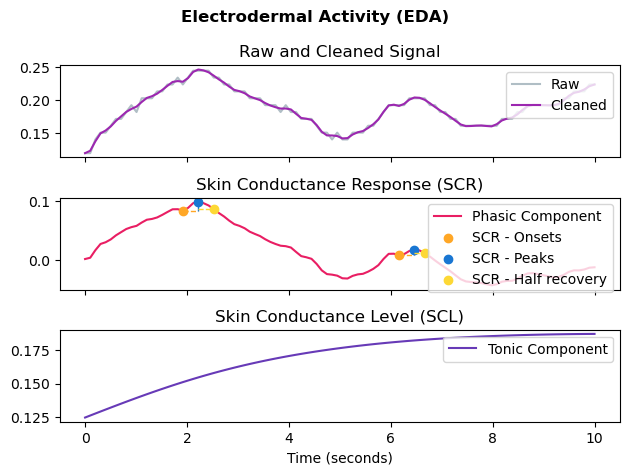

Participant_02_SB_638670921404187796_17_emotion_FRUSTRATED_game_canvas_painter.npy


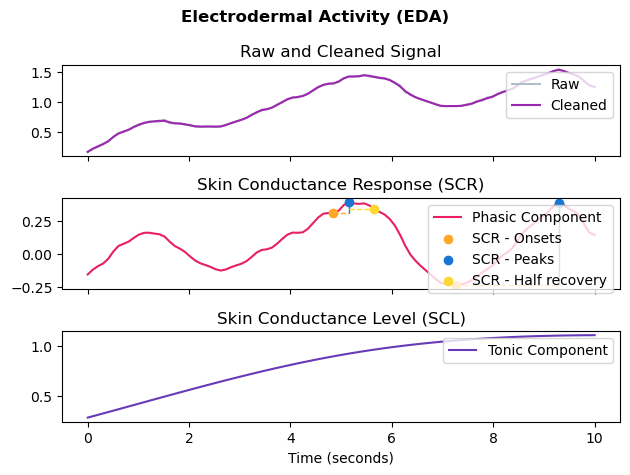

Participant_20_C_638695234858389888_1_emotion_FRUSTRATED_game_color_words.npy


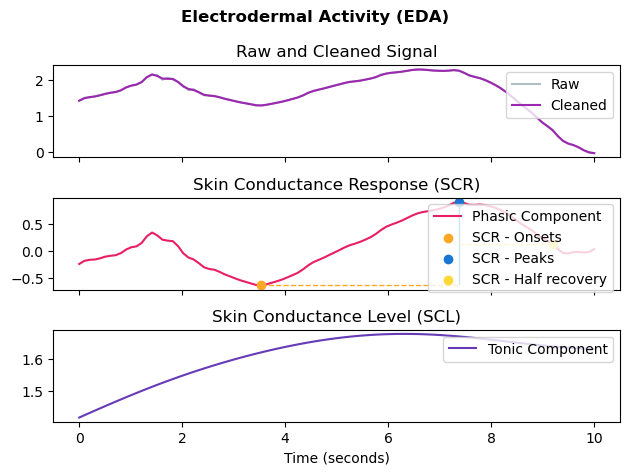

Participant_05_PM_638675335914492531_18_emotion_FRUSTRATED_game_tower_of_hanoi.npy


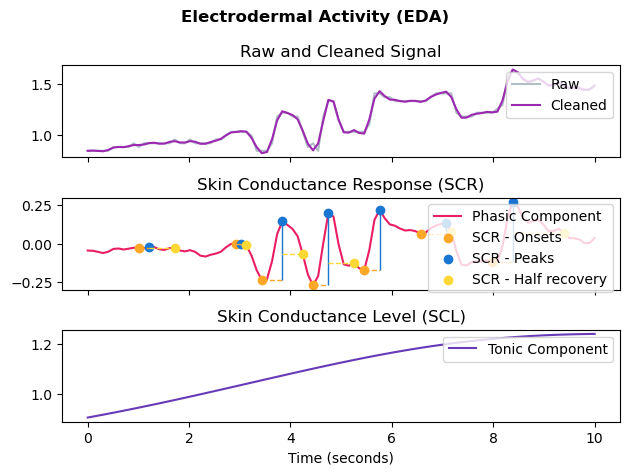

Participant_06_JB_638676166472715506_18_emotion_BORED_game_color_words.npy


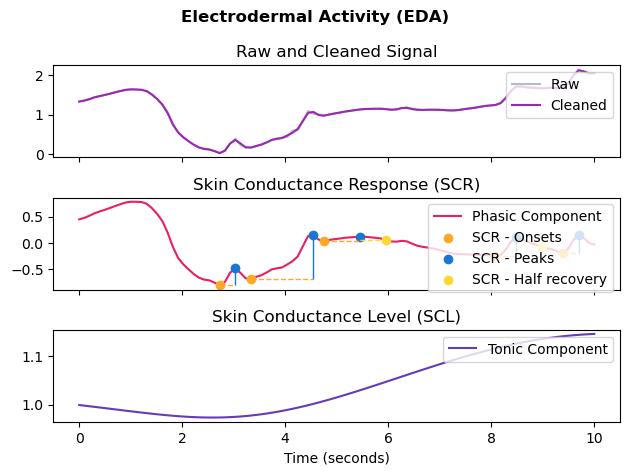

In [61]:
# Processed data
processed_samples = get_processed_samples(ssl_dir, 5, visualize=False)
for sample in processed_samples:
    print(sample["filename"])

    # EDA / GSR
    eda_signals, eda_info = nk.eda_process(sample["gsr"], sampling_rate=10)

    eda_fig = nk.eda_plot(eda_signals, eda_info)
    plt.tight_layout()
    plt.show()

    # PPG
    # ppg_signals, ppg_info = nk.ppg_process(sample["ppg"], sampling_rate=20)

    # ppg_fig = nk.ppg_plot(ppg_signals, ppg_info)
    # plt.tight_layout()
    # plt.show()

In [55]:
eda_signals

,EDA_Raw,EDA_Clean,EDA_Tonic,EDA_Phasic,SCR_Onsets,SCR_Peaks,SCR_Height,SCR_Amplitude,SCR_RiseTime,SCR_Recovery,SCR_RecoveryTime
0,-0.158421,-0.158420,-0.062763,-0.118936,0,0,0.0,0.0,0.0,0,0.0
1,-0.158421,-0.159710,-0.062020,-0.121421,0,0,0.0,0.0,0.0,0,0.0
2,-0.180615,-0.180702,-0.061198,-0.143684,0,0,0.0,0.0,0.0,0,0.0
3,-0.202789,-0.200860,-0.060295,-0.165190,0,0,0.0,0.0,0.0,0,0.0
4,-0.202789,-0.203432,-0.059309,-0.169188,0,0,0.0,0.0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
95,-0.047145,-0.046923,0.095346,-0.023321,0,0,0.0,0.0,0.0,0,0.0
96,-0.047145,-0.059927,0.095310,-0.030179,0,0,0.0,0.0,0.0,0,0.0
97,-0.113971,-0.093675,0.095275,-0.057632,0,0,0.0,0.0,0.0,0,0.0
98,-0.091716,-0.106876,0.095242,-0.064387,0,0,0.0,0.0,0.0,0,0.0


In [56]:
eda_info

{'SCR_Onsets': array([19], dtype=int64),
 'SCR_Peaks': array([59], dtype=int64),
 'SCR_Height': array([0.51798278]),
 'SCR_Amplitude': array([0.89556728]),
 'SCR_RiseTime': array([4.]),
 'SCR_Recovery': array([73.]),
 'SCR_RecoveryTime': array([1.4]),
 'sampling_rate': 10}

In [57]:
nk.eda_intervalrelated(eda_signals, sample_rate=10)


,SCR_Peaks_N,SCR_Peaks_Amplitude_Mean,EDA_Tonic_SD,EDA_Sympathetic,EDA_SympatheticN,EDA_Autocorrelation
0,1.0,0.895567,0.057398,NaN,NaN,NaN


In [ ]:
def extract_eda_features_from_raw(
    gsr_window,
    sampling_rate=10
):
    """
    Extract basic EDA features from a raw GSR window.

    Parameters
    ----------
    gsr_window : array-like, shape (n_samples,)
        Raw GSR signal (e.g. 5 seconds at 10 Hz)
    sampling_rate : int or float
        Sampling rate in Hz

    Returns
    -------
    features : dict
        Flat dictionary of scalar features
    """

    features = {}

    # ---------------------
    # NeuroKit processing
    # ---------------------
    try:
        eda_signals, eda_info = nk.eda_process(
            gsr_window,
            sampling_rate=sampling_rate
        )
    except Exception:
        # Fail-safe: return NaNs if preprocessing explodes
        return {k: np.nan for k in [
            "phasic_mean", "phasic_std", "phasic_max", "phasic_rms",
            "phasic_auc", "phasic_d1_mean_abs", "phasic_d1_max_abs",
            "tonic_mean", "tonic_std", "tonic_min", "tonic_max",
            "tonic_slope", "tonic_delta",
            "scr_count", "scr_rate",
            "scr_amp_mean", "scr_amp_max", "scr_amp_sum",
            "scr_risetime_mean", "scr_risetime_std"
        ]}

    tonic = eda_signals["EDA_Tonic"].values
    phasic = eda_signals["EDA_Phasic"].values

    n_samples = len(phasic)
    duration = n_samples / sampling_rate

    # ---------------------
    # PHASIC FEATURES
    # ---------------------
    features["phasic_mean"] = np.mean(phasic)
    features["phasic_std"] = np.std(phasic)
    features["phasic_max"] = np.max(phasic)
    features["phasic_rms"] = np.sqrt(np.mean(phasic ** 2))
    features["phasic_auc"] = np.sum(phasic) / n_samples

    d_phasic = np.diff(phasic)
    features["phasic_d1_mean_abs"] = np.mean(np.abs(d_phasic))
    features["phasic_d1_max_abs"] = np.max(np.abs(d_phasic))

    # ---------------------
    # TONIC FEATURES
    # ---------------------
    features["tonic_mean"] = np.mean(tonic)
    features["tonic_std"] = np.std(tonic)
    features["tonic_min"] = np.min(tonic)
    features["tonic_max"] = np.max(tonic)

    t = np.arange(n_samples) / sampling_rate
    features["tonic_slope"] = np.polyfit(t, tonic, 1)[0]
    features["tonic_delta"] = tonic[-1] - tonic[0]

    # ---------------------
    # SCR EVENT FEATURES
    # ---------------------
    scr_amplitudes = np.asarray(eda_info.get("SCR_Amplitude", []))
    scr_rise_times = np.asarray(eda_info.get("SCR_RiseTime", []))

    # Drop NaNs explicitly
    scr_amplitudes = scr_amplitudes[~np.isnan(scr_amplitudes)]
    scr_rise_times = scr_rise_times[~np.isnan(scr_rise_times)]

    n_scr = len(scr_amplitudes)

    features["scr_count"] = n_scr
    features["scr_rate"] = n_scr / duration

    if n_scr > 0:
        features["scr_amp_mean"] = np.mean(scr_amplitudes)
        features["scr_amp_max"] = np.max(scr_amplitudes)
        features["scr_amp_sum"] = np.sum(scr_amplitudes)
        features["scr_risetime_mean"] = np.mean(scr_rise_times)
        features["scr_risetime_std"] = np.std(scr_rise_times)
    else:
        # Explicit zeros encode "no arousal"
        features["scr_amp_mean"] = 0.0
        features["scr_amp_max"] = 0.0
        features["scr_amp_sum"] = 0.0
        features["scr_risetime_mean"] = 0.0
        features["scr_risetime_std"] = 0.0

    return features

In [64]:
processed_samples = get_processed_samples(ssl_dir, 5, visualize=False)
features = extract_eda_features_from_raw(processed_samples[1]["gsr"])
features


{'phasic_mean': 0.000615904154626231,
 'phasic_std': 0.08459952980903515,
 'phasic_max': 0.09046941832346507,
 'phasic_rms': 0.08460177174171657,
 'phasic_auc': 0.000615904154626231,
 'phasic_d1_mean_abs': 0.006235836691049261,
 'phasic_d1_max_abs': 0.019294578318287653,
 'tonic_mean': -2.137175421827015,
 'tonic_std': 0.2071076944857674,
 'tonic_min': -2.5263720848297555,
 'tonic_max': -1.885287888258924,
 'tonic_slope': 0.07063104425777128,
 'tonic_delta': 0.6410841965708316,
 'scr_count': 9,
 'scr_rate': 0.9,
 'scr_amp_mean': 0.024244435063773002,
 'scr_amp_max': 0.058713846541011,
 'scr_amp_sum': 0.21819991557395702,
 'scr_risetime_mean': 0.5,
 'scr_risetime_std': 0.39440531887330776}

# PyEDA

In [22]:
import sys
sys.path.append('..')
from pyEDA.main import *

In [ ]:
# stack all gsr values from this list of dictionaries  
processed_samples = get_processed_samples(ssl_dir, 10, visualize=False)
processed_gsr = np.stack([d['data'][:,0] for d in processed_samples])
processed_gsr.shape

(50, 2)

In [ ]:
m, wd, eda_clean = process_statistical(sample['data'][:,0], use_scipy=True, sample_rate=10, new_sample_rate=40, segment_width=600, segment_overlap=0)

print(m)
print(wd)
print(eda_clean)

If you are using this tool for your research please cite this paper: "pyEDA: An Open-Source Python Toolkit for Pre-processing and Feature Extraction of Electrodermal Activity"
     pcost       dcost       gap    pres   dres
 0: -7.0414e+01 -7.0249e+01  2e+02  1e+01  6e+01
 1: -7.0182e+01 -7.3386e+01  3e+00  2e-01  8e-01
 2: -7.0270e+01 -7.0572e+01  3e-01  1e-02  5e-02
 3: -7.0378e+01 -7.0419e+01  4e-02  1e-04  5e-04
 4: -7.0400e+01 -7.0416e+01  2e-02  4e-05  2e-04
 5: -7.0408e+01 -7.0416e+01  8e-03  2e-05  6e-05
 6: -7.0414e+01 -7.0415e+01  1e-03  2e-06  8e-06
 7: -7.0415e+01 -7.0415e+01  4e-04  5e-07  2e-06
 8: -7.0415e+01 -7.0415e+01  3e-04  3e-07  1e-06
 9: -7.0415e+01 -7.0415e+01  6e-05  5e-08  2e-07
10: -7.0415e+01 -7.0415e+01  2e-05  7e-09  3e-08
11: -7.0415e+01 -7.0415e+01  5e-06  5e-10  2e-09
12: -7.0415e+01 -7.0415e+01  1e-07  1e-11  6e-11
13: -7.0415e+01 -7.0415e+01  1e-09  2e-13  7e-13
Optimal solution found.


(dict, dict, list)

In [35]:
prepare_automatic(processed_gsr, sample_rate=10, new_sample_rate=40, k=32, epochs=100, batch_size=10)

If you are using this tool for your research please cite this paper: "pyEDA: An Open-Source Python Toolkit for Pre-processing and Feature Extraction of Electrodermal Activity"
epoch : 1/100, loss = 0.424007
epoch : 2/100, loss = 0.382998
epoch : 3/100, loss = 0.353125
epoch : 4/100, loss = 0.332324
epoch : 5/100, loss = 0.318272
epoch : 6/100, loss = 0.309158
epoch : 7/100, loss = 0.303551
epoch : 8/100, loss = 0.300376
epoch : 9/100, loss = 0.298740
epoch : 10/100, loss = 0.297847
epoch : 11/100, loss = 0.297108
epoch : 12/100, loss = 0.296090
epoch : 13/100, loss = 0.294491
epoch : 14/100, loss = 0.292028
epoch : 15/100, loss = 0.288380
epoch : 16/100, loss = 0.283103
epoch : 17/100, loss = 0.275896
epoch : 18/100, loss = 0.266438
epoch : 19/100, loss = 0.254926
epoch : 20/100, loss = 0.242040
epoch : 21/100, loss = 0.228780
epoch : 22/100, loss = 0.216311
epoch : 23/100, loss = 0.205518
epoch : 24/100, loss = 0.196416
epoch : 25/100, loss = 0.188557
epoch : 26/100, loss = 0.181603
e

In [36]:
automatic_features = process_automatic(processed_gsr[0])
automatic_features

Loading the network...


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x50 and 200x128)